In [1]:
import numpy as np
from jax import numpy as jnp
from jax import random
from numpyro.infer import MCMC, NUTS, init_to_sample
from numpyro.distributions import Normal, Uniform
from numpyro import plate, sample, factor
from numpyro.handlers import scale
from tqdm import trange
from corner import corner

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
def ll_calibration_xtrue_marginalised(x_obs, Sigma_x, x_cal, Sigma_cal, Delta, Mu, Sigma):
    return -((Delta**2 * Sigma**2 + Delta**2 * Sigma_cal**2 + 
                2 * Delta * Mu * Sigma_cal**2 + Mu**2 * Sigma_cal**2 +
                x_obs**2 * (Sigma**2 + Sigma_cal**2) -
                2 * x_obs * (Delta * Sigma**2 + (Delta + Mu) * Sigma_cal**2) +
                Mu**2 * Sigma_x**2 + x_cal**2 * (Sigma**2 + Sigma_x**2) -
                2 * x_cal * ((x_obs - Delta) * Sigma**2 + Mu * Sigma_x**2)) /
               (2 * (Sigma_cal**2 * Sigma_x**2 + Sigma**2 * (Sigma_cal**2 + Sigma_x**2)))) - \
             0.5 * jnp.log(1 / Sigma**2 + 1 / Sigma_cal**2 + 1 / Sigma_x**2) - \
             jnp.log(2 * np.pi * Sigma * Sigma_cal * Sigma_x)

In [61]:
def model(xobs, e_xobs, xcal, e_xcal, cal_mask, not_cal_mask, with_calibration=True):
    xmu = sample("xmu", Uniform(-5, 5))
    xstd = sample('xstd', Uniform(0.001, 5.))

    if with_calibration:
        dx = sample("dx", Uniform(-5, 5))
        # with plate('data', len(xobs)):
            # ll = ll_calibration_xtrue_marginalised(xobs, e_xobs, xcal, e_xcal, dx, xmu, xstd)
            # factor('ll_xobs', ll)
        ll0 = ll_calibration_xtrue_marginalised(
            xobs[cal_mask], e_xobs[cal_mask], xcal[cal_mask], e_xcal[cal_mask],
            dx, xmu, xstd)
        ll1 = Normal(xmu + dx, jnp.sqrt(xstd**2 + e_xobs[not_cal_mask]**2)).log_prob(xobs[not_cal_mask])

        factor("ll", jnp.sum(ll0) + jnp.sum(ll1))
    else:
        with plate('data', len(xobs)):
            sample("obs", Normal(xmu, jnp.sqrt(xstd**2 + e_xobs**2)), obs=xobs)

    # dx = sample("dx", Uniform(-5, 5))

    # with plate('data', len(xobs)):
    #     xtrue = sample('xtrue', Normal(xmu, xstd))
    #     factor('ll_xobs', Normal(xtrue + dx, e_xobs).log_prob(xobs))
    

    # with plate("calibration", len(xcal)):
    #     factor("ll_xcal", Normal(xtrue[cal_mask], e_xcal).log_prob(xcal))


In [91]:
nsamples = 1000
with_calibration = True

x0_mean = 0.
x0_std = 1.0
sigma_x = 0.1
sigma_cal = sigma_x / 1
dx = 0.4

def gen_data(seed, verbose=True):
    gen = np.random.default_rng(seed)
    xtrue = gen.normal(x0_mean, x0_std, nsamples)
    xobs = dx + gen.normal(xtrue, sigma_x)
    e_xobs = np.ones_like(xobs) * sigma_x

    mu = np.percentile(xobs, 1) 
    cal_mask = xobs < mu
    # cal_mask = jnp.arange(nsamples) % 125 == 0
    not_cal_mask = ~cal_mask
    if verbose:
        print(f"Calibration is for {cal_mask.sum()} galaxies out of {len(cal_mask)}.")

    xcal = gen.normal(xtrue, sigma_cal)
    e_xcal = np.ones_like(xcal) * sigma_cal

    xcal[~cal_mask] = jnp.nan
    e_xcal[~cal_mask] = jnp.nan

    return xobs, e_xobs, xcal, e_xcal, cal_mask, not_cal_mask




In [88]:
seed = 43

xobs, e_xobs, xcal, e_xcal, cal_mask, not_cal_mask = gen_data(seed)
nuts_kernel = NUTS(model, init_strategy=init_to_sample())
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=2500, progress_bar=True)
mcmc.run(random.PRNGKey(0), xobs, e_xobs, xcal, e_xcal, cal_mask, not_cal_mask, with_calibration=with_calibration)
samples = mcmc.get_samples()
mcmc.print_summary()


Calibration is for 10 galaxies out of 1000.


sample: 100%|██████████| 3500/3500 [00:03<00:00, 1044.84it/s, 3 steps of size 3.94e-01. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        dx      0.37      0.04      0.37      0.30      0.45   1024.89      1.00
       xmu      0.01      0.06      0.01     -0.08      0.10   1015.97      1.00
      xstd      1.00      0.02      1.00      0.96      1.04   1623.12      1.00

Number of divergences: 0


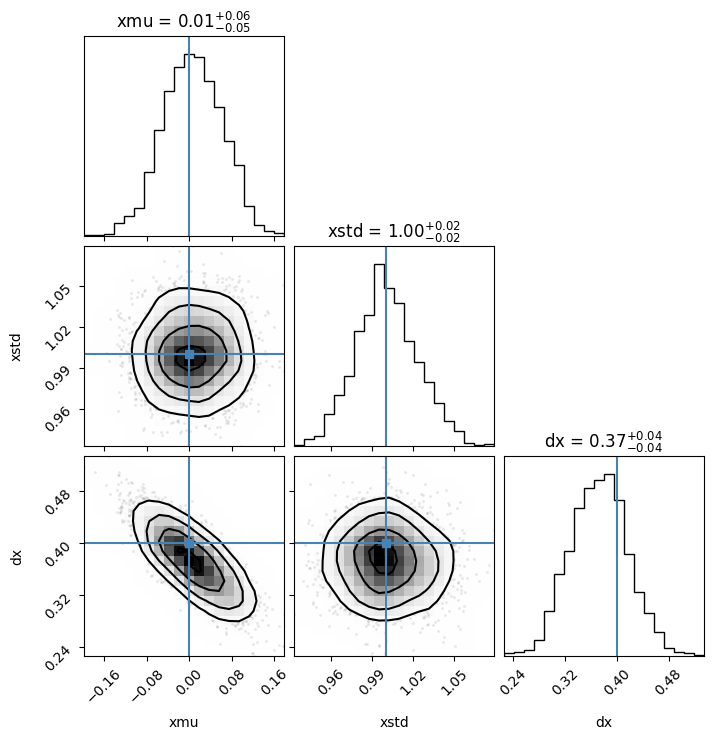

In [89]:
data = np.vstack([samples['xmu'], samples['xstd'], samples['dx']]).T
fig = corner(data, labels=['xmu', 'xstd', 'dx'], truths=[x0_mean, x0_std, dx],
             smooth=1,  show_titles=True)

In [92]:
def run_single(seed, verbose):
    xobs, e_xobs, xcal, e_xcal, cal_mask, not_cal_mask = gen_data(seed, verbose)
    nuts_kernel = NUTS(model, init_strategy=init_to_sample())
    mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=2500, progress_bar=verbose)
    mcmc.run(random.PRNGKey(0), xobs, e_xobs, xcal, e_xcal, cal_mask, not_cal_mask, with_calibration=with_calibration)
    samples = mcmc.get_samples()
    # mcmc.print_summary()

    dx_inferred = samples['dx']

    return (dx_inferred.mean() - dx) / dx_inferred.std()


In [98]:
nrepeat = 300
dx_bias = np.full(nrepeat, np.nan)
for n in trange(nrepeat):
    dx_bias[n] = run_single(n, False)



100%|██████████| 300/300 [10:08<00:00,  2.03s/it]


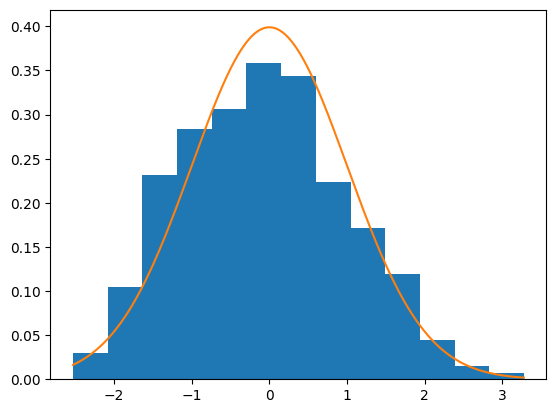

In [99]:
from scipy.stats import norm

plt.figure()
plt.hist(dx_bias, bins="auto", density=1)
x = np.linspace(dx_bias.min(), dx_bias.max(), 1000)
plt.plot(x, norm.pdf(x, 0, 1))
plt.show()

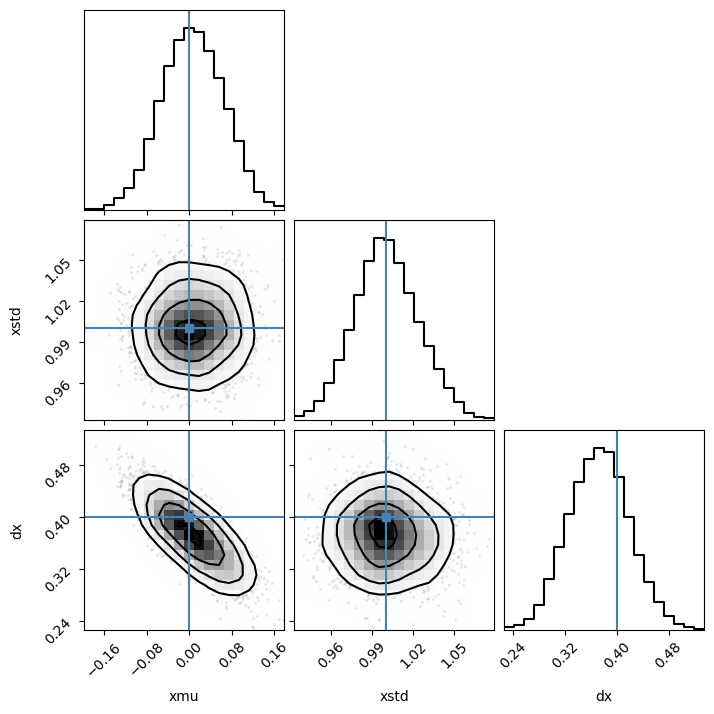

In [97]:
if with_calibration:
    data = np.stack([samples['xmu'], samples['xstd'], samples["dx"]], axis=-1)
    labels = ['xmu', 'xstd', 'dx']
    truths = [x0_mean, x0_std, dx]
else:
    data = np.stack([samples['xmu'], samples['xstd']], axis=-1)
    labels = ['xmu', 'xstd']
    truths = [x0_mean, x0_std]

fig = corner(data, labels=labels, smooth=1, smooth1d=1, truths=truths)
fig.show()

In [ ]:
plt.figure()
plt.scatter(xobs, np.mean(samples["xtrue"], axis=0))

plt.axline([0, 0], [1, 1], color='red', ls="--")
plt.show()